# Trajectories: a simple figure workflow

Load one recording, select each figure's data with the slicer, define the plotting
functions, then call them. Paths use pixels and the acquired recording clock.
The original notebooks are kept alongside this example.

## 1. Set up the DataStructure and load the recording

Run this notebook in the project environment, with `data-conduit/src` on Python's
import path. Change the mouse, day and recording below to load another session.

In [8]:
# --- Imports -----------------------------------------------------------------
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import movement.kinematics as kin
import numpy as np
import pandas as pd

from data_conduit.datastructures import slice_stream, slice_stream_for_trial
from data_conduit.integrations.DLC.pose import pose_to_movement
from movement_figures.data_template.loading import build_datastructure
from movement_figures.video import read_session_video_frame

# --- Recording and requested streams -----------------------------------------
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
SESSION = "2026-06-21T093349Z"
data = build_datastructure(
    ROOT,
    level_names=("mouseID", "day"),
    l0_selector="MR_M01569515",
    l1_selector="Day21",
    # include=(SESSION,),
    streams=("trials", "dlc"),
)
session_id, recording = next(iter(data.select().items()))
streams = data.load()
background_frame, video_path = read_session_video_frame(recording.path)

## 2. Slice the data needed for the figures

Select original trial numbers 1–8, then select the matching pose stream. Keep the
body keypoint and mask confidence below 0.9; missing positions stay missing.
The trial parser already supplies outbound and inbound segment boundaries.

In [9]:
# --- Choose trial rows and one tracked point ----------------------------------
trials = slice_stream(
    streams["trials"],
    selectors={"session": session_id, "trial_index": slice(1, 8)},
).copy()  # Trial-index slices include both endpoints.
trials["outcome"] = trials["outcome"].fillna("Unknown")
pose = pose_to_movement(
    slice_stream(streams["dlc:position"], selectors={"session": session_id}),
    slice_stream(streams["dlc:confidence"], selectors={"session": session_id}),
)
body = pose.sel(keypoint="body", individual="individual_0", drop=True)
point = body.position.where(body.confidence >= 0.9)

# --- Figure 1: outbound and inbound paths for each selected trial --------------
phase_paths = {}
for _, trial in trials.iterrows():
    for phase in ("outbound", "inbound"):
        phase_paths[(trial.trial_index, phase)] = slice_stream_for_trial(
            point, trial, segment=phase, time_coord="time",
        )  # The trial row supplies recording, time bounds and inclusion flags.
trials

,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,...,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day
0,1,5633.836992,5667.029120,True,True,1,12,5663.198976,5640.910976,0,...,5663.198976,True,True,5663.198976,5667.029120,True,True,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,False,True,13,27,5678.849984,5675.540992,0,...,5678.849984,False,True,5678.849984,5681.075968,True,True,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,False,True,28,42,5693.349984,5690.241984,0,...,5693.349984,False,True,5693.349984,5695.245088,True,True,2026-06-21T093349Z,MR_M01569515,Day21
3,4,5695.245088,5709.933824,False,True,43,56,5707.698976,5697.756000,0,...,5707.698976,False,True,5707.698976,5709.933824,True,True,2026-06-21T093349Z,MR_M01569515,Day21
4,5,5709.933824,5721.442080,False,True,57,71,5719.708992,5719.392000,0,...,5719.708992,False,True,5719.708992,5721.442080,True,True,2026-06-21T093349Z,MR_M01569515,Day21
5,6,5721.442080,5727.532608,False,True,72,85,5726.500992,5723.960000,0,...,5726.500992,False,True,5726.500992,5727.532608,True,True,2026-06-21T093349Z,MR_M01569515,Day21
6,7,5727.532608,5736.700960,False,True,86,100,5735.050976,5734.158976,0,...,5735.050976,False,True,5735.050976,5736.700960,True,True,2026-06-21T093349Z,MR_M01569515,Day21
7,8,5736.700960,5743.183072,False,True,101,114,5741.900992,5739.190976,0,...,5741.900992,False,True,5741.900992,5743.183072,True,True,2026-06-21T093349Z,MR_M01569515,Day21


Outbound length is the sum of distances between successive tracked positions.
Inbound deviation is the mean perpendicular distance from the line joining the
inbound path's observed endpoints. Both are distances in pixels; outbound length
is a provisional complexity measure.

Measurements need at least two samples and no missing positions. Inbound endpoints
must differ to define their reference line. Unavailable measurements stay `NaN`
in `metrics`; the comparison uses trials with both measurements available.

In [10]:
# --- Figure 2: calculate measurements from the selected paths ------------------
records = []
for _, trial in trials.iterrows():
    outbound = phase_paths[(trial.trial_index, "outbound")]
    inbound = phase_paths[(trial.trial_index, "inbound")]
    length, deviation = np.nan, np.nan

    # Avoid movement's default gap filling when a path contains missing samples.
    if outbound.sizes["time"] >= 2 and bool(np.isfinite(outbound).all()):
        length = float(kin.compute_path_length(outbound))
    if inbound.sizes["time"] >= 2 and bool(np.isfinite(inbound).all()):
        endpoint_distance = float(np.linalg.norm(inbound.isel(time=-1) - inbound.isel(time=0)))
        if endpoint_distance > 0:
            deviation = float(kin.compute_path_deviation(inbound).mean("time"))

    records.append({
        "trial_index": trial.trial_index,
        "outcome": trial.outcome,
        "outbound_path_length": length,
        "inbound_mean_deviation": deviation,
    })
metrics = pd.DataFrame(records)
comparison_data = slice_stream(
    metrics,
    where=lambda rows: rows[["outbound_path_length", "inbound_mean_deviation"]].notna().all(axis=1),
)
metrics

,trial_index,outcome,outbound_path_length,inbound_mean_deviation
0,1,Success,NaN,NaN
1,2,Success,NaN,160.429861
2,3,Success,NaN,131.671985
3,4,Success,NaN,NaN
4,5,Success,1300.540054,51.553620
5,6,Success,287.108208,41.368891
6,7,Success,1186.207021,30.961853
7,8,Success,NaN,61.105529


## 3. Define the figure functions

These functions draw the inputs already selected above. All spatial panels use
frame zero of the selected recording, with the same pixel coordinates as DLC.

In [11]:
# --- Figure 1: paths grouped by outcome ---------------------------------------
def plot_path_grid(phase_paths, 
                   trials, 
                   frame
                   ):
    """Draw outbound and inbound paths over the first video frame.

    Parameters
    ----------
    phase_paths : dict
        Selected xarray (time, space) paths in pixels, keyed by
        (original trial_index, "outbound" or "inbound").
    trials : pandas.DataFrame
        Selected rows from one recording, with trial_index and outcome columns.
    frame : numpy.ndarray
        First RGB video frame from that recording, in its original pixel size.

    Returns
    -------
    matplotlib.figure.Figure
        Two columns of paths, one row per outcome, with a trial-number colourbar.
    """
    # Set up the panel layout and a shared colour for each trial.
    outcomes = trials.outcome.unique()
    first_trial, last_trial = trials.trial_index.min(), trials.trial_index.max()
    norm = Normalize(first_trial, max(first_trial + 1, last_trial))
    cmap = plt.get_cmap("viridis")
    fig, axes = plt.subplots(
        len(outcomes), 2, figsize=(11, 4 * len(outcomes)),
        squeeze=False, layout="constrained",
    )
    height, width = frame.shape[:2]
    extent = (-0.5, width - 0.5, height - 0.5, -0.5)

    # Keep image y increasing downwards, matching DLC coordinates.
    for row, outcome in enumerate(outcomes):
        panel_trials = trials.loc[trials.outcome.eq(outcome)]
        for column, phase in enumerate(("outbound", "inbound")):
            ax = axes[row, column]
            ax.imshow(frame, extent=extent, origin="upper", alpha=0.55)
            for trial in panel_trials.itertuples():
                path = phase_paths[(trial.trial_index, phase)]
                ax.scatter(
                    path.sel(space="x"), path.sel(space="y"),
                    s=4, color=cmap(norm(trial.trial_index)), alpha=0.7,
                )  # Scatter preserves gaps without connecting missing positions.
            ax.set(
                title=f"{outcome}: {phase}", xlabel="x (px)", ylabel="y (px)",
                xlim=extent[:2], ylim=extent[2:], aspect="equal",
            )
    colourbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes.ravel().tolist())
    colourbar.set_ticks(sorted(trials.trial_index.unique()))
    colourbar.set_label("Original trial index")
    fig.suptitle("Selected body trajectories")
    return fig

In [12]:
# --- Figure 2: outbound length against inbound deviation ----------------------
def plot_length_vs_deviation(pairs):
    """Compare the two path measurements for each eligible trial.

    Parameters
    ----------
    pairs : pandas.DataFrame
        Selected trial rows with outcome, outbound_path_length and
        inbound_mean_deviation columns. Both distances are finite pixel values.

    Returns
    -------
    matplotlib.figure.Figure
        Scatter plot with one dot per trial and colour identifying its outcome.
    """
    fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
    colours = {"Success": "#23775a", "Miss": "#c27b12", "Failure": "#b94148"}
    for outcome, rows in pairs.groupby("outcome", sort=False):
        ax.scatter(
            rows.outbound_path_length, rows.inbound_mean_deviation,
            color=colours.get(outcome, "#657183"), label=outcome, s=38, alpha=0.8,
        )  # Each dot joins measurements from the same trial.
    ax.set(
        xlabel="Outbound path length (px)", ylabel="Mean inbound deviation (px)",
        title=f"Outbound length vs inbound deviation: {len(pairs)} trials",
        xlim=(0, None), ylim=(0, None),
    )
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)
    if len(pairs):
        ax.legend(title="Outcome")
    return fig

## 4. Call the functions and return the figures

Rerun these cells to redraw the selected data. Change the selection in section 2
and rerun it first when choosing different trials.

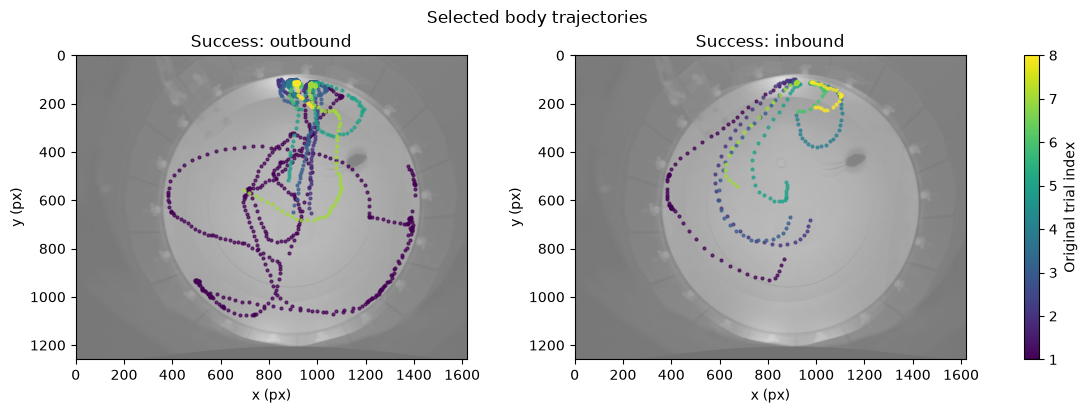

In [13]:
path_fig = plot_path_grid(phase_paths, trials, background_frame)
plt.close(path_fig)  # Display the returned figure once below.
path_fig


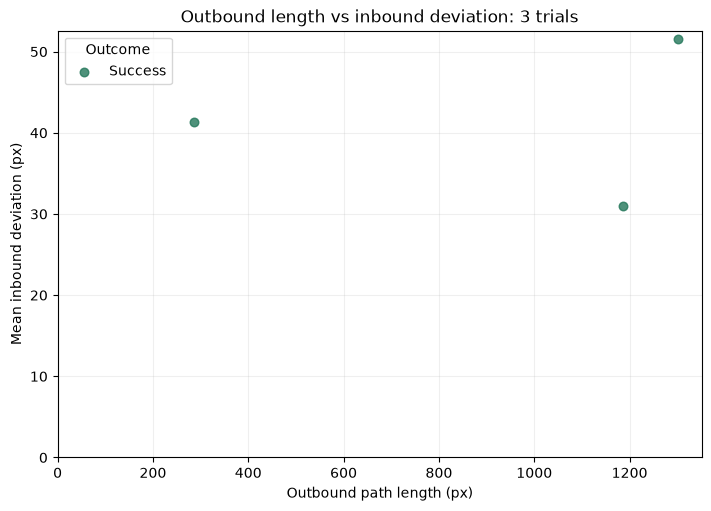

In [14]:
comparison_fig = plot_length_vs_deviation(comparison_data)
plt.close(comparison_fig)  # Display the returned figure once below.
comparison_fig
